# 02 - Tabu Search

Tabu Search es una metaheuristica de trayectoria: mantiene una sola solucion actual y la mueve por su vecindario. Su rasgo distintivo es la **memoria**: algunos movimientos recientes se declaran tabu para evitar ciclos y forzar exploracion.


## 1. Idea general

En una busqueda local clasica solo se aceptan movimientos que mejoran. Tabu Search permite moverse incluso a soluciones peores si eso ayuda a escapar de optimos locales. Para no volver inmediatamente al mismo punto, mantiene una lista tabu por varias iteraciones.

Conceptos clave:

- **Vecindario**: soluciones alcanzables con un cambio pequeno.
- **Tenure**: cantidad de iteraciones durante las cuales un atributo queda prohibido.
- **Aspiracion**: se permite romper la regla tabu si el movimiento produce la mejor solucion global vista.


## 2. Codigo base generico

Este motor minimiza una funcion `cost`. El usuario entrega una solucion inicial, una funcion de vecinos y la funcion de costo. Cada vecino viene acompanado de un atributo de movimiento para administrar la memoria tabu.


In [1]:
import math
import itertools
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)


def make_tsp_instance(n=20, seed=42):
    """Crea una instancia reproducible de ciudades en el plano [0, 1] x [0, 1]."""
    rng = np.random.default_rng(seed)
    return rng.random((n, 2))


def distance_matrix(coords):
    """Calcula la matriz de distancias euclidianas entre ciudades."""
    diff = coords[:, None, :] - coords[None, :, :]
    return np.sqrt((diff ** 2).sum(axis=2))


def tour_length(tour, D):
    """Costo total de una ruta cerrada que vuelve al punto inicial."""
    return float(sum(D[tour[i], tour[(i + 1) % len(tour)]] for i in range(len(tour))))


def plot_tour(coords, tour, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    closed = list(tour) + [tour[0]]
    xy = coords[closed]
    ax.plot(xy[:, 0], xy[:, 1], marker="o", linewidth=1.8)
    for idx, (x, y) in enumerate(coords):
        ax.text(x + 0.008, y + 0.008, str(idx), fontsize=8)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal", adjustable="box")
    return ax


def plot_convergence(history, title, ylabel="Mejor costo", ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))
    ax.plot(history, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Iteracion")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    return ax


In [2]:
def tabu_search(initial, neighbors, cost, tenure=10, max_iter=200):
    """Tabu Search generico para minimizacion."""
    current = initial.copy() if hasattr(initial, "copy") else initial
    current_cost = cost(current)
    best = current.copy() if hasattr(current, "copy") else current
    best_cost = current_cost
    tabu_until = {}
    history = [best_cost]

    for it in range(1, max_iter + 1):
        candidates = []
        for move_attr, candidate in neighbors(current):
            c = cost(candidate)
            is_tabu = tabu_until.get(move_attr, -1) >= it
            aspiration = c < best_cost
            if (not is_tabu) or aspiration:
                candidates.append((c, move_attr, candidate))

        if not candidates:
            break

        current_cost, move_attr, current = min(candidates, key=lambda x: x[0])
        tabu_until[move_attr] = it + tenure

        if current_cost < best_cost:
            best = current.copy() if hasattr(current, "copy") else current
            best_cost = current_cost

        history.append(best_cost)

    return best, best_cost, history


## 3. Ejemplo: TSP con vecindario 2-opt

El problema del viajante (TSP) busca visitar todas las ciudades una vez y volver al inicio con la menor distancia posible. Usaremos un movimiento **2-opt**: elegir dos posiciones de la ruta e invertir el segmento intermedio.

La memoria tabu se guarda sobre el par de posiciones invertidas. Asi se evita deshacer inmediatamente el mismo cambio.


In [3]:
coords = make_tsp_instance(n=20, seed=42)
D = distance_matrix(coords)
n = len(coords)
start_tour = np.arange(n)


def tsp_cost(tour):
    return tour_length(tour, D)


def two_opt_neighbors(tour):
    result = []
    for i in range(1, n - 1):
        for j in range(i + 1, n):
            candidate = tour.copy()
            candidate[i:j] = candidate[i:j][::-1]
            move_attr = (int(i), int(j))
            result.append((move_attr, candidate))
    return result

best_tour, best_len, hist = tabu_search(
    start_tour, two_opt_neighbors, tsp_cost, tenure=12, max_iter=180
)

print(f"Longitud inicial: {tsp_cost(start_tour):.3f}")
print(f"Mejor longitud Tabu Search: {best_len:.3f}")
print(f"Mejora porcentual: {(1 - best_len / tsp_cost(start_tour)) * 100:.1f}%")
print(f"Iteraciones registradas: {len(hist) - 1}")


Longitud inicial: 10.296
Mejor longitud Tabu Search: 4.270
Mejora porcentual: 58.5%
Iteraciones registradas: 180


### Explicacion general del codigo ejemplo

1. `start_tour` define una ruta inicial simple.
2. `two_opt_neighbors` genera todas las rutas que resultan de invertir un segmento.
3. `tsp_cost` mide la distancia total de una ruta cerrada.
4. `tabu_search` elige el mejor vecino admisible, aunque sea peor que la solucion actual.
5. La lista tabu reduce ciclos y la aspiracion permite aceptar un movimiento tabu si mejora el record global.


<notebook-cell>:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


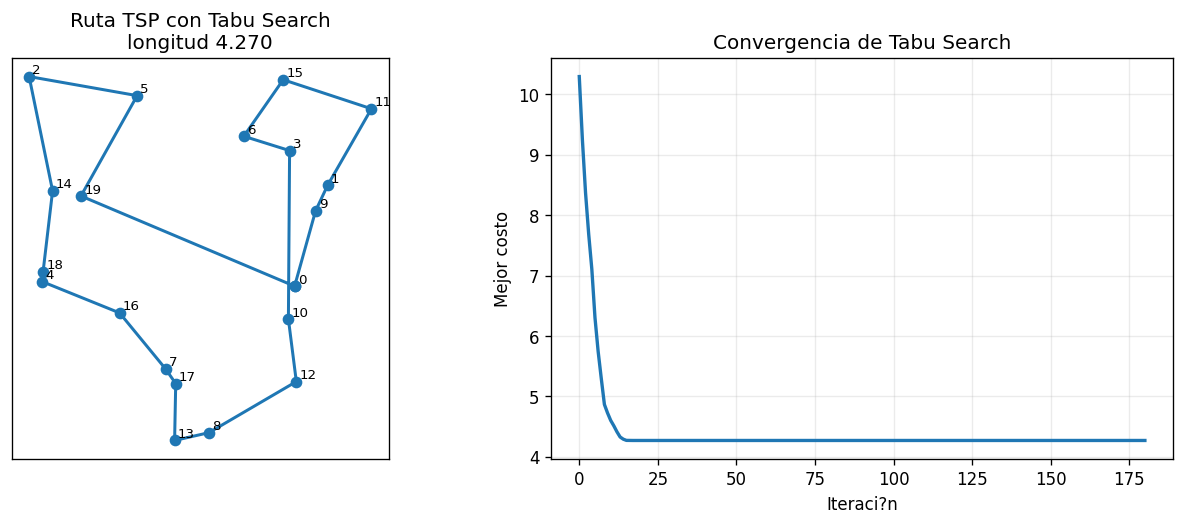

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_tour(coords, best_tour, f"Ruta TSP con Tabu Search\nlongitud {best_len:.3f}", ax=axes[0])
plot_convergence(hist, "Convergencia de Tabu Search", ax=axes[1])
plt.tight_layout()
plt.show()


## 4. Parametros, ventajas y limites

El parametro mas sensible es el **tenure**. Si es muy corto, la busqueda puede ciclar; si es muy largo, puede prohibir movimientos utiles. Tabu Search funciona bien cuando existe un vecindario natural y barato de evaluar, pero puede requerir ajuste cuidadoso de memoria, aspiracion y criterios de parada.
